# IIGBM: Functional ANOVA, Model-Induced Kernels and Component Curvature

This notebook builds an inherently interpretable gradient boosting model and reads it
with three quantities, all derived from the fitted model:

1. **fANOVA order** &mdash; which features act alone (main effects) and which act in pairs.
2. **Importance** $A_S$ &mdash; how much variation a component explains.
3. **Curvature** $Q_S$ &mdash; whether that component is broad and smooth or sharp and local.

Importance says *which* learned effects matter; curvature says *how* each behaves locally.

> **Environment.** Run this with the `torchgpu` kernel (Python 3.11, xgboost 3.0, pandas 2.2).
> Under pandas 3.0 xgboost drops DataFrame feature names and the interaction constraints below fail.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# Reuse the pipeline functions so the notebook matches the paper exactly.
from california_housing_deep_anova_kernel_curvature import (
    xgb, background_predictions, model_kernel_curvature, SumModel, main_effect_table,
)

pd.set_option('display.float_format', lambda v: f'{v:.5f}')
RNG = np.random.default_rng(0)

## 1. A fitted tree is already a kernel

Before any ANOVA, a single tree induces a similarity. Route a point $x$ to its leaf
$\ell(x)$ and write the one-hot leaf vector $z(x)=e_{\ell(x)}$. Two points are *similar*
when they land in the same leaf:

$$K_T(x,x') = z(x)^\top z(x') = \mathbf{1}\{\ell(x)=\ell(x')\}.$$

Stacking points into $Z$ makes the Gram matrix $K=ZZ^\top$, so $K_T$ is positive
semidefinite. A boosted ensemble sums these per-tree kernels, so two points are close when
the ensemble *repeatedly* routes them together. The demo below shows the co-membership
matrix for a handful of points under one shallow tree.

In [2]:
data = fetch_california_housing(as_frame=True)
X_all = data.data.copy()
y_all = np.log1p(data.target.to_numpy(float))   # positive target -> log1p

demo = X_all.iloc[:8]
leaf = DecisionTreeRegressor(max_depth=3, random_state=0).fit(X_all, y_all).apply(demo)
co = (leaf[:, None] == leaf[None, :]).astype(int)   # 1{same leaf}
print('leaf id per point:', leaf)
print('leaf co-membership kernel (8 points):')
print(co)

leaf id per point: [14 14 13 10  6  6  6  6]
leaf co-membership kernel (8 points):
[[1 1 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 0 0 1 1 1 1]
 [0 0 0 0 1 1 1 1]
 [0 0 0 0 1 1 1 1]
 [0 0 0 0 1 1 1 1]]


## 2. The data and the staged model

We predict $\log(1+\texttt{MedHouseVal})$ on California housing. The construction has three
stages:

- **Stage I (GAM).** An XGBoost model where each tree may split only one feature, so the
  model is additive: $f_1(x)=\sum_j f_j(x_j)$. Deep univariate trees give flexible main
  effects while additivity holds exactly.
- **Stage II (screen).** Fit a depth-2 model to the GAM residual; each root&ndash;child path
  is a candidate feature pair, ranked by split gain.
- **Stage III (deep).** Refit a deep model on the residual, constrained to the screened pairs.

The interaction constraints are what keep the model readable: the deep model can only use
the pairs we selected.

In [3]:
Xtr, Xte, ytr, yte = train_test_split(X_all, y_all, test_size=0.2, random_state=0)
Xtr, Xte = Xtr.reset_index(drop=True), Xte.reset_index(drop=True)
cols = list(Xtr.columns)
print('features:', cols)
print('train', Xtr.shape, 'test', Xte.shape)

features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
train (16512, 8) test (4128, 8)


In [4]:
# Stage I: additive GAM (each feature is its own interaction group)
gam = xgb(10, [[c] for c in cols]).fit(Xtr, ytr)
gam_mae = np.abs(gam.predict(Xte) - yte).mean()
print(f'GAM (main effects only) test MAE: {gam_mae:.4f}')

GAM (main effects only) test MAE: 0.1294


In [5]:
# Stage II: depth-2 screen on the GAM residual -> ranked feature pairs
def screen_pairs(model, k=6):
    df = model.get_booster().trees_to_dataframe()
    score = {}
    for _, tree in df.groupby('Tree'):
        root = tree[tree.Node == 0]
        if root.empty or root.iloc[0].Feature == 'Leaf':
            continue
        a = root.iloc[0].Feature
        for _, ch in tree[tree.Node.isin([1, 2])].iterrows():
            if ch.Feature in ('Leaf', a):
                continue
            key = tuple(sorted((a, ch.Feature)))
            score[key] = score.get(key, 0.0) + float(ch.Gain)
    return sorted(score.items(), key=lambda kv: -kv[1])[:k]

screen = xgb(2).fit(Xtr, ytr - gam.predict(Xtr))
pairs = [p for p, _ in screen_pairs(screen, k=6)]
print('screened pairs:')
for a, b in pairs:
    print(f'  {a} x {b}')

screened pairs:
  Latitude x Longitude
  AveOccup x MedInc
  AveRooms x MedInc
  MedInc x Population
  AveOccup x Latitude
  AveOccup x AveRooms


In [6]:
# Stage III: deep residual model constrained to the screened pairs
deep = xgb(6, [list(p) for p in pairs]).fit(Xtr, ytr - gam.predict(Xtr))
full = SumModel(gam, deep)                 # f = f_1 + g_deep
full_mae = np.abs(full.predict(Xte) - yte).mean()
print(f'GAM + screened deep test MAE: {full_mae:.4f}  (GAM was {gam_mae:.4f})')

GAM + screened deep test MAE: 0.1045  (GAM was 0.1294)


## 3. fANOVA components and importance $A_S$

A component isolates one effect by a background contrast. For a pair $S=\{j,k\}$ and a
background sample $B$,

$$\Psi_{jk}(x) = g(x_j,x_k,B_{-jk}) - g(x_j,B_{-j}) - g(x_k,B_{-k}) + g(B),$$

averaged over background draws. The double subtraction removes the two main effects and the
constant, leaving the pair interaction. We compute components of the full model $f$, so
first-order contrasts give main effects and second-order contrasts give interactions.
Importance is the variance of the centered component, $A_S=\mathrm{Var}(g_S)$.

component Latitude x Longitude:  A_S (variance) = 0.00807


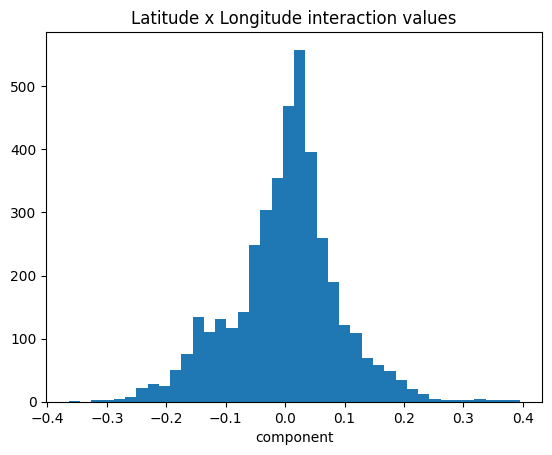

In [7]:
background = Xtr.iloc[RNG.choice(len(Xtr), size=96, replace=False)].reset_index(drop=True)
base = full.predict(background)[None, :]

def pair_component(a, b):
    hab = background_predictions(full, Xte, background, [a, b])
    ha  = background_predictions(full, Xte, background, [a])
    hb  = background_predictions(full, Xte, background, [b])
    psi = hab - ha - hb + base            # (n_points, n_background)
    comp = psi.mean(axis=1)
    return comp - comp.mean(), psi        # centered component + feature map

a, b = pairs[0]
comp, psi = pair_component(a, b)
print(f'component {a} x {b}:  A_S (variance) = {np.var(comp):.5f}')
plt.hist(comp, bins=40); plt.title(f'{a} x {b} interaction values'); plt.xlabel('component'); plt.show()

## 4. Model-induced kernel and curvature $Q_S$

The contrast vectors $\Psi_S(x)$ form a PSD kernel $K_S(x,x')=\tfrac1M\Psi_S(x)^\top\Psi_S(x')$:
the same recipe as the leaf kernel in Section 1, but the feature map is now the deep model's
*interaction response* instead of leaf indicators.

Curvature asks whether the component changes gently or abruptly across points that are close
in this kernel. Build a $k$-NN graph in $\Psi_S$-space; for each node subtract the weighted
average of its neighbors' values, $c_S=(I-W)g_S$ (a graph Laplacian). The roughness is the
mean of $c_S^2$. To make it comparable across components of any size, divide by the same
roughness under random permutations of the values over the graph:

$$Q_S = \frac{R(g_S)}{\mathbb{E}_\pi\,R(g_S\circ\pi)}.$$

$Q_S$ below 1 is smoother than chance; near 1 means no smoothness signal (rough, or too few
distinct states to resolve). It is invariant to the component's amplitude and to how many
states it has.

In [8]:
q, raw, states = model_kernel_curvature(psi / np.sqrt(psi.shape[1]), comp)
print(f'{a} x {b}:  Q_S = {q:.4f}   (roughness {raw:.2e}, {states} distinct states)')
print('Q_S < 1  -> smoother than a random labeling on the same graph')

Latitude x Longitude:  Q_S = 0.0145   (roughness 1.25e-04, 2970 distinct states)
Q_S < 1  -> smoother than a random labeling on the same graph


## 5. Importance and curvature for every component

The same two numbers apply to main effects and interactions. We tabulate both and plot
them together.

In [9]:
# main effects (first-order contrasts of the full model)
changed_of = {c: [c] for c in cols}
mains = main_effect_table(full, Xte, background, cols, changed_of)
mains = mains.rename(columns={'feature': 'component'})
mains['order'] = 'main'

# interactions (second-order contrasts)
rows = []
for a, b in pairs:
    comp_ab, psi_ab = pair_component(a, b)
    q_ab, _, st = model_kernel_curvature(psi_ab / np.sqrt(psi_ab.shape[1]), comp_ab)
    rows.append({'component': f'{a} x {b}', 'anova_energy': float(np.var(comp_ab)),
                 'model_kernel_curvature': q_ab, 'kernel_states': st, 'order': 'interaction'})
inter = pd.DataFrame(rows)

tab = pd.concat([mains[['component', 'order', 'anova_energy', 'model_kernel_curvature', 'kernel_states']],
                 inter[['component', 'order', 'anova_energy', 'model_kernel_curvature', 'kernel_states']]],
                ignore_index=True)
tab = tab.rename(columns={'anova_energy': 'A_importance', 'model_kernel_curvature': 'Q_curvature'})
tab.sort_values('A_importance', ascending=False)

,component,order,A_importance,Q_curvature,kernel_states
0,Longitude,main,0.05438,0.00747,236
1,Latitude,main,0.04599,0.01432,209
2,MedInc,main,0.02308,0.00831,256
8,Latitude x Longitude,interaction,0.00807,0.01450,2970
3,AveOccup,main,0.00586,0.00378,256
4,AveRooms,main,0.00209,0.02952,256
10,AveRooms x MedInc,interaction,0.00119,0.03443,3884
9,AveOccup x MedInc,interaction,0.00028,0.05818,4001
11,MedInc x Population,interaction,0.00020,0.11654,3984
5,AveBedrms,main,0.00019,0.08495,239


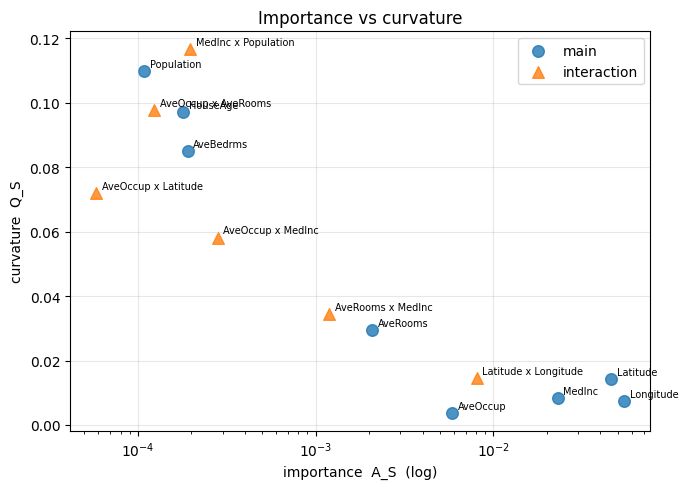

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
for order, marker in [('main', 'o'), ('interaction', '^')]:
    sub = tab[tab.order == order]
    ax.scatter(sub.A_importance, sub.Q_curvature, marker=marker, s=70, label=order, alpha=0.8)
for _, r in tab.iterrows():
    ax.annotate(r.component, (r.A_importance, r.Q_curvature), fontsize=7,
                xytext=(4, 3), textcoords='offset points')
ax.set_xscale('log'); ax.set_xlabel('importance  A_S  (log)'); ax.set_ylabel('curvature  Q_S')
ax.set_title('Importance vs curvature'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Reading the $(A_S, Q_S)$ map

- **High $A$, low $Q$** &mdash; an important broad effect. Summarize it with a simple trend.
- **High $A$, high $Q$** &mdash; an important effect built from thresholds or regimes. Plot it;
  a small input change can move the prediction sharply.
- **Low $A$, high $Q$** &mdash; a weak effect on sparse support. Inspect for data coverage, do
  not act on it directly.
- **$Q\approx 1$** &mdash; no smoothness signal, often a low-cardinality feature.

The plots below contrast a smooth main effect with a more curved one.

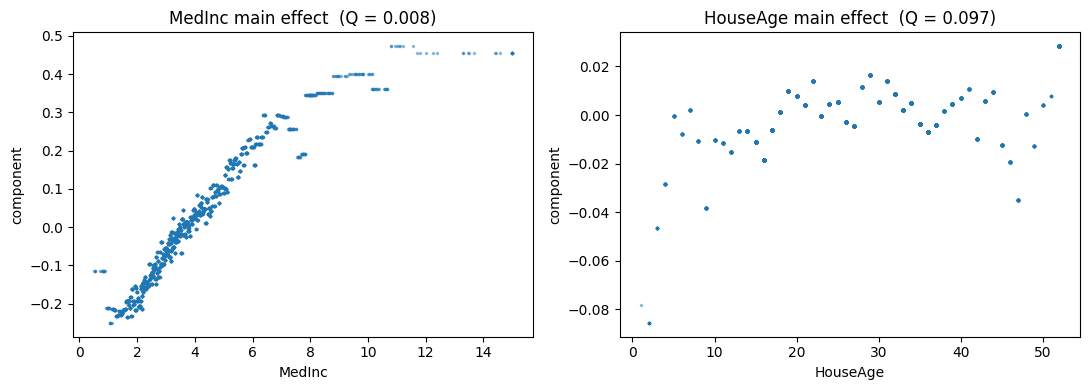

In [11]:
def main_component(feat):
    h = background_predictions(full, Xte, background, [feat])
    m = h.mean(axis=1); return m - m.mean()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for axi, feat in zip(ax, ['MedInc', 'HouseAge']):
    v = main_component(feat)
    o = np.argsort(Xte[feat].to_numpy())
    axi.plot(Xte[feat].to_numpy()[o], v[o], '.', ms=3, alpha=0.4)
    qf = float(tab.loc[tab.component == feat, 'Q_curvature'].iloc[0])
    axi.set_title(f'{feat} main effect  (Q = {qf:.3f})'); axi.set_xlabel(feat); axi.set_ylabel('component')
plt.tight_layout(); plt.show()

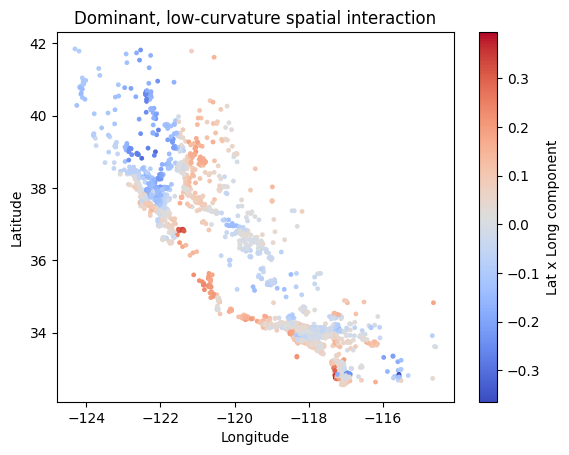

In [12]:
# the Latitude x Longitude interaction as a spatial surface
cll, _ = pair_component('Latitude', 'Longitude')
sc = plt.scatter(Xte['Longitude'], Xte['Latitude'], c=cll, s=6, cmap='coolwarm')
plt.colorbar(sc, label='Lat x Long component'); plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title('Dominant, low-curvature spatial interaction'); plt.show()

## Summary

- A fitted GBDT induces a PSD kernel from leaf membership; the same recipe, applied to the
  deep model's interaction responses, gives a per-component kernel.
- fANOVA importance $A_S$ ranks components; component curvature $Q_S$ describes their local
  shape.
- $Q_S$ is normalized by a permutation null, so it is comparable across main effects and
  interactions of any cardinality, with $Q_S\approx 1$ flagging components too coarse to read.

The full method, proofs and a curvature validation are in `iigbm_model_induced_curvature.tex`.